# Trajectory Analysis

In molecular dynamics (MD) simulations, analyzing conformational dynamics and structural fluctuations across trajectories is fundamental. MolSysMT provides a unified set of tools to load trajectories from multiple formats, align structures, and compute time-dependent physical observables such as RMSD, RMSF, radius of gyration, and inter-atomic distances.


## Loading a Trajectory

We begin by loading an MD trajectory of a pentalanine peptide bundled with MolSysMT:


In [1]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt
from molsysmt import pyunitwizard as puw

traj_file = msm.systems['pentalanine']['traj_pentalanine.h5msm']
molsys = msm.convert(traj_file, to_form='molsysmt.MolSys')


Let us inspect the system dimensions and topology:


In [2]:
msm.info(molsys)


form,n_atoms,n_groups,n_components,n_chains,n_molecules,n_entities,n_peptides,n_structures
molsysmt.MolSys,62,7,1,1,1,1,1,100


In [3]:
n_structures, n_atoms = msm.get(molsys, n_structures=True, n_atoms=True)
print(f"Loaded trajectory containing {n_structures} structures and {n_atoms} atoms.")


Loaded trajectory containing 100 structures and 62 atoms.


## Structural Superposition

To remove global translational and rotational movements before computing structural deviations, we fit all frames against the first structure using {func}`molsysmt.structure.least_rmsd_fit`:


In [4]:
molsys = msm.structure.least_rmsd_fit(molsys, selection_fit="atom_name=='CA'", reference_structure_index=0)


## Root Mean Square Deviation

We compute the C-alpha Root Mean Square Deviation (RMSD) across time relative to the initial structure using {func}`molsysmt.structure.get_rmsd`:


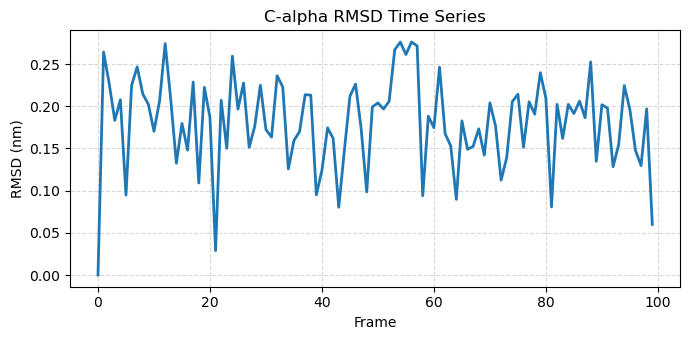

In [5]:
rmsd = msm.structure.get_rmsd(molsys, selection="atom_name=='CA'", reference_structure_index=0)
rmsd_val = puw.get_value(rmsd, to_unit='nm')

plt.figure(figsize=(7, 3.5))
plt.plot(rmsd_val, color='#1f77b4', lw=2)
plt.xlabel('Frame')
plt.ylabel('RMSD (nm)')
plt.title('C-alpha RMSD Time Series')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Root Mean Square Fluctuation

To identify which residues fluctuate most during the simulation, we calculate the per-residue Root Mean Square Fluctuation (RMSF) using {func}`molsysmt.structure.get_rmsf`:


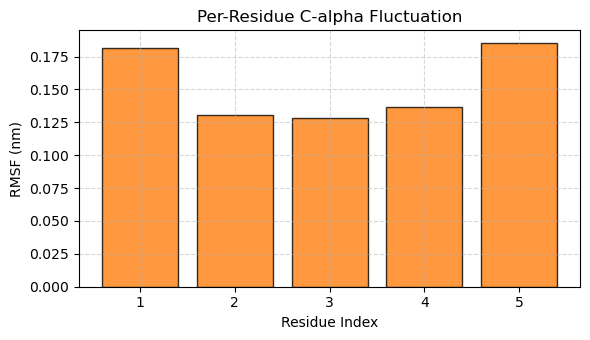

In [6]:
rmsf = msm.structure.get_rmsf(molsys, selection="atom_name=='CA'")
rmsf_val = puw.get_value(rmsf, to_unit='nm')

plt.figure(figsize=(6, 3.5))
plt.bar(range(1, len(rmsf_val) + 1), rmsf_val, color='#ff7f0e', edgecolor='black', alpha=0.8)
plt.xlabel('Residue Index')
plt.ylabel('RMSF (nm)')
plt.title('Per-Residue C-alpha Fluctuation')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Radius of Gyration

The radius of gyration measures the overall compactness of the peptide structure over time using {func}`molsysmt.structure.get_radius_of_gyration`:


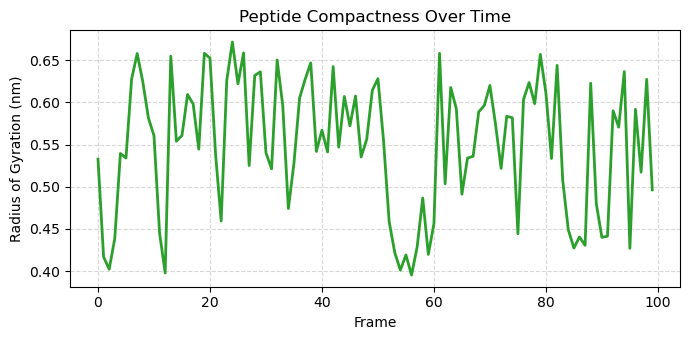

In [7]:
rg = msm.structure.get_radius_of_gyration(molsys, selection='all')
rg_val = puw.get_value(rg, to_unit='nm')

plt.figure(figsize=(7, 3.5))
plt.plot(rg_val, color='#2ca02c', lw=2)
plt.xlabel('Frame')
plt.ylabel('Radius of Gyration (nm)')
plt.title('Peptide Compactness Over Time')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## End-to-End Distance

We can also monitor internal distance metrics, such as the distance between terminal C-alpha atoms across all trajectory frames using {func}`molsysmt.structure.get_distances`:


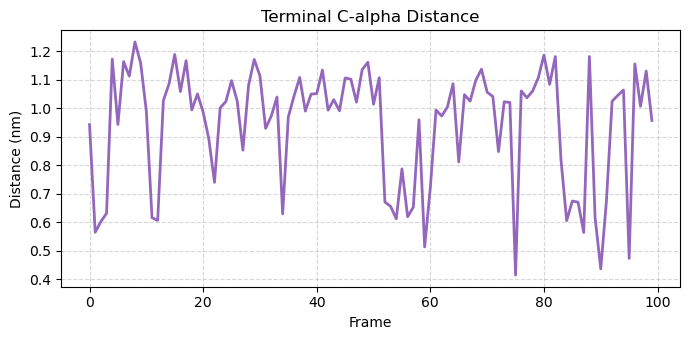

In [8]:
end_to_end = msm.structure.get_distances(molsys, selection="group_index==1 and atom_name=='CA'", selection_2="group_index==5 and atom_name=='CA'")
end_to_end_val = puw.get_value(end_to_end[:, 0, 0], to_unit='nm')

plt.figure(figsize=(7, 3.5))
plt.plot(end_to_end_val, color='#9467bd', lw=2)
plt.xlabel('Frame')
plt.ylabel('Distance (nm)')
plt.title('Terminal C-alpha Distance')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Extracting Conformations

We can extract specific conformational states from the trajectory, such as the frame with minimum radius of gyration (most compact conformation) using {func}`molsysmt.basic.extract`:


In [9]:
min_rg_frame = int(np.argmin(rg_val))
compact_molsys = msm.extract(molsys, structure_indices=min_rg_frame)
print(f"Extracted most compact structure at frame {min_rg_frame}.")


Extracted most compact structure at frame 56.


## Interactive Visualization

Finally, we visualize the trajectory in 3D with MolSysViewer:


In [10]:
msm.view(molsys)


'<iframe src="../../_static/views/showcase_md_trajectory.html" width="100%" height="480px" style="border:none;"></iframe>'